# Проект: Исследование стартапов

## Введение

Финансовая компания хочет изучить рынок инвестиций и понять, какие стартапы наиболее перспективны. У компании нет достоверных и полных исторических данных, поэтому при исследовании стоит быть осторожным с выводанми. 


## Шаг 1. Знакомство с данными: загрузка и первичная предобработка

### 1.1. Вывод общей информации, исправление названия столбцов


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

In [2]:
palette = ['#0398fc', '#0d5382', '#073a5c', '#3776a1', '#6da8d1', '#84b6d9']

In [3]:
aquis = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
car = pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
degree = pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')
education = pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
people = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')

In [4]:
aquis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


In [5]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217472 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id            52928 non-nul

В датасете два столбца ('company_ID' и 'company_id') с одинаковой информацией, удалим один из них.

In [6]:
car.drop(columns=['company  id'], inplace=True)
car = car.rename(columns={'company  ID': 'company_id'})
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company_id             217472 non-null  float64
 1   name                   217472 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  funded  at             52680 non-nul

In [7]:
degree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


In [8]:
education.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


In [9]:
people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


### 1.2. Смена типов и анализ пропусков

Первое, что я хочу сделать, это привести названия столбцов в датасете company_and_rounds к snake_case. Еще в этом датасете есть два столбца с одинаковыми данными, так что пусть один будет "первым", в другой- "вторым". 

In [10]:
def col_to_snake_case(data):
    new_columns = {}
    for col in data.columns:
        str_bad = col.replace('  ', '_')
        str_good = str_bad[0].lower() + str_bad[1:]
        for index_s, item_s in enumerate(str_good):
            if item_s.isupper():
                str_good = str_good[:index_s] + '_' + str_good[index_s].lower() + str_good[index_s + 1:]
        new_columns[col] = str_good
    return data.rename(columns=new_columns)

car = col_to_snake_case(car)

car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   company_id           217472 non-null  float64
 1   name                 217472 non-null  object 
 2   category_code        143886 non-null  object 
 3   status               217472 non-null  object 
 4   founded_at           109956 non-null  object 
 5   closed_at            3449 non-null    object 
 6   domain               147159 non-null  object 
 7   network_username     95534 non-null   object 
 8   country_code         108607 non-null  object 
 9   investment_rounds    217472 non-null  float64
 10  funding_rounds       217472 non-null  float64
 11  funding_total        217472 non-null  float64
 12  milestones           217472 non-null  float64
 13  funding_round_id     52928 non-null   float64
 14  funded_at            52680 non-null   object 
 15  funding_round_typ

Во всех датасетах поменяю тип данных на время для столбцов, в которых хранятся даты.

In [11]:
aquis['acquired_at'] = pd.to_datetime(aquis['acquired_at'], errors='coerce')
print(aquis.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    9407 non-null   int64         
 1   acquiring_company_id  9407 non-null   int64         
 2   acquired_company_id   9407 non-null   int64         
 3   term_code             1831 non-null   object        
 4   price_amount          9407 non-null   int64         
 5   acquired_at           9378 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 441.1+ KB
None


In [12]:
car['founded_at'] = pd.to_datetime(car['founded_at'], errors='coerce')
car['closed_at'] = pd.to_datetime(car['closed_at'], errors='coerce')
car['funded_at'] = pd.to_datetime(car['funded_at'], errors='coerce')
car['company_id'] = car['company_id'].astype('Int64')
car['investment_rounds'] = car['investment_rounds'].astype('Int64')
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id           217472 non-null  Int64         
 1   name                 217472 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  Int64         
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

In [13]:
education['graduated_at'] = pd.to_datetime(education['graduated_at'], errors='coerce')
print(education.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            109610 non-null  int64         
 1   person_id     109610 non-null  int64         
 2   instituition  109555 non-null  object        
 3   graduated_at  58054 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 3.3+ MB
None


Предварительно хочу сказать, что очень много пропусков в данных. В таблице с данными о раундах инвестирования с информацией об окончании финансирования всего 3500 значений из 220 тыс. И так во всех датасетах есть хотя бы один столбец с большим количеством пропсуков. Но основной инфомации для анализа должно хватить.

## Шаг 2. Предобработка данных, предварительное исследование


### 2.1. Раунды финансирования по годам

Рассчитаю, сколько денег в среднем получали компании за год и какое количество раундов финансирования было проведено. Для дальнейшего анализа оставлю только года, в которые было проведено более 50 раундов финансирования.

In [14]:
years = car['funded_at'].dt.year

pivot_table = car.groupby(years).agg(
    average_funding=('raised_amount', 'median'),
    amount_round=('raised_amount', 'count')
).reset_index()

pivot_table

,funded_at,average_funding,amount_round
0,1960.0,0.0,9
1,1973.0,0.0,1
2,1974.0,0.0,2
3,1984.0,41000.0,3
4,1985.0,0.0,1
5,1987.0,1250000.0,2
6,1989.0,15000.0,1
7,1990.0,1000000.0,1
8,1992.0,2000000.0,1
9,1993.0,62500.0,2


In [15]:
car['funded_at'] = car['funded_at'].apply(lambda x: x.year if pd.notnull(x) else pd.NA).astype('Int64')

car = car.loc[car['funded_at'] >= 1999]

pivot_table2 = car.groupby('funded_at').agg(
    average_funding=('raised_amount', 'median'),
    amount_round=('raised_amount', 'count')
).reset_index()

pivot_table2

,funded_at,average_funding,amount_round
0,1999,2000000.0,76
1,2000,4200000.0,125
2,2001,3000000.0,96
3,2002,4200000.0,116
4,2003,3000000.0,159
5,2004,5000000.0,291
6,2005,5500000.0,1633
7,2006,5000000.0,2436
8,2007,3973320.0,3279
9,2008,3110000.0,3774


Визуализируем тенденцию:

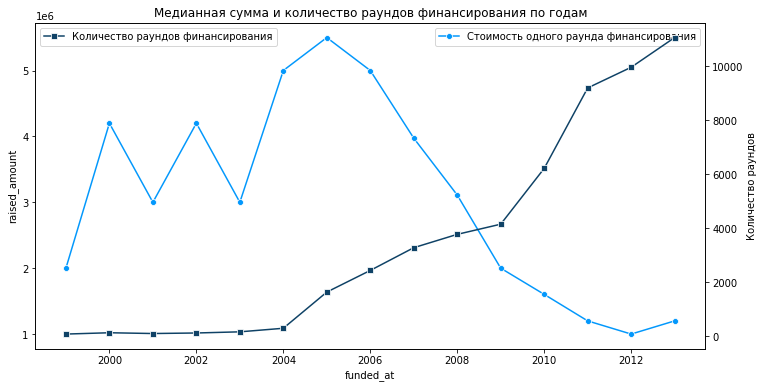

In [16]:
funding = car.groupby('funded_at')['raised_amount'].median().reset_index()
rounds = car.groupby('funded_at')['raised_amount'].count().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=funding, x='funded_at', y='raised_amount', marker='o', color='#0398fc', label='Стоимость одного раунда финансирования')

ax2 = plt.gca().twinx()
sns.lineplot(data=rounds, x='funded_at', y='raised_amount', marker='s', color='#0f4266', label='Количество раундов финансирования')

plt.title('Медианная сумма и количество раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Стоимость одного раунда')
ax2.set_ylabel('Количество раундов')
ax2.set_xlabel('Год')

plt.grid(False)
plt.xticks(rotation=45)
plt.show()

В 2006 году в среднем компании получили наибольшее финансирование. После 2006 года идет тенденция к снижение объема финансирования. При этом количество раундов финансирования увеличивается, проверим как изменяется сумма финансирования за все раунды:

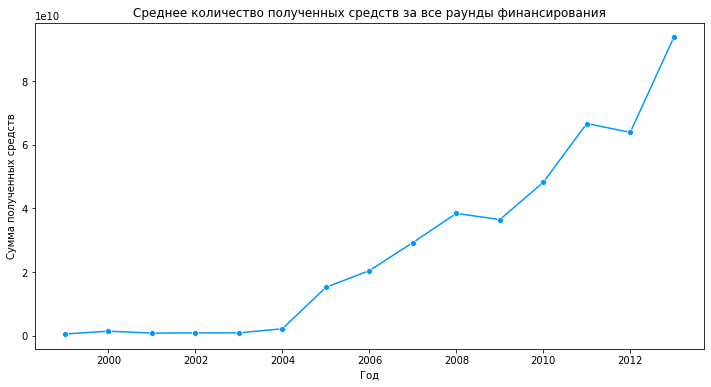

In [17]:
aggregated = car.groupby('funded_at').agg(
    mean_raised_amount=('raised_amount', 'mean'),
    count_raised_amount=('raised_amount', 'count')
).reset_index()

aggregated['mean_per_count'] = aggregated['mean_raised_amount'] * aggregated['count_raised_amount']

plt.figure(figsize=(12, 6))
sns.lineplot(data=aggregated, x='funded_at', y='mean_per_count', marker='o', color='#0398fc')

plt.title('Среднее количество полученных средств за все раунды финансирования')
plt.xlabel('Год')
plt.ylabel('Сумма полученных средств')
plt.grid(False)
plt.show()

Не смотря на то, что сумма финансирования за раунд с 2006 падала, количество раундов компенсировало это и суммарно компании получали больше денег. Вероятно, снижение среднего произошло из-за того, что финансировать стали даже очень маленькие компании, а им нужны были меньшие вложения.


### 2.2. Люди и их образование

Посмотрим, зависит ли полнота сведений об их образовании сотрудников от размера компаний. Для этого разделим компании по количеству сотрудников на четыре группы.

In [18]:
people = people.rename(columns={'id': 'id_people'})
people.head(5)

,id_people,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


In [19]:
education = education.rename(columns={'id': 'id_education'})
education.head(5)

,id_education,person_id,instituition,graduated_at
0,1,6117,NaN,NaT
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaT


In [20]:
df_workers = pd.merge(education, people, left_on='person_id', right_on='id_people', how='outer')
df_workers.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 268248 entries, 0 to 268247
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id_education      109610 non-null  float64       
 1   person_id         109610 non-null  float64       
 2   instituition      109555 non-null  object        
 3   graduated_at      58054 non-null   datetime64[ns]
 4   id_people         267694 non-null  float64       
 5   first_name        267689 non-null  object        
 6   last_name         267693 non-null  object        
 7   company_id        44789 non-null   float64       
 8   network_username  50775 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 20.5+ MB


In [21]:
cnt = {}
for i in df_workers['company_id']:
    if pd.notnull(i):
        if i in cnt:
            cnt[i] += 1
        else:
            cnt[i] = 1

max_value = max(cnt.values())
print(f'Максимальное значение: {max_value}')

Максимальное значение: 376


In [22]:
bins = [0, 94, 188, 282, 376]

labels = ['меньше 94 сотрудников', 'меньше 188 сотрудников', 'меньше 282 сотрудников', 'меньше 376 сотрудников']

df_workers['group'] = pd.cut(df_workers['company_id'], bins=bins, labels=labels, right=False)

In [23]:
for group in labels:
    group_df = df_workers[df_workers['group'] == group]
    
    if not group_df.empty:
        missing_ratio = group_df['instituition'].isnull().mean()
        print(f'Если в компании {group} информации об образовании нет у {missing_ratio:.2%} сотрудников')

Если в компании меньше 94 сотрудников информации об образовании нет у 26.42% сотрудников
Если в компании меньше 188 сотрудников информации об образовании нет у 39.42% сотрудников
Если в компании меньше 282 сотрудников информации об образовании нет у 37.90% сотрудников
Если в компании меньше 376 сотрудников информации об образовании нет у 36.10% сотрудников


In [24]:
degree = degree.rename(columns={'id': 'id_degree'})
degree.head(5)

,id_degree,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


Разделила все компании на четыре равные группы по количеству сотрудников. Посчитала для каждой группы процент сотрудников, для которых отсутствует запись об образовании. В целом, логично, что при увеличении количества записей получалось большее число сотрудников без данных. Попробуем присоединить датафрейм degree и посмотреть, изменятся ли показатели.

In [25]:
df_full = pd.merge(df_workers, degree, left_on='id_people', right_on='id_degree', how='outer')
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 284333 entries, 0 to 284332
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id_education      109610 non-null  float64       
 1   person_id         109610 non-null  float64       
 2   instituition      109555 non-null  object        
 3   graduated_at      58054 non-null   datetime64[ns]
 4   id_people         267694 non-null  float64       
 5   first_name        267689 non-null  object        
 6   last_name         267693 non-null  object        
 7   company_id        44789 non-null   float64       
 8   network_username  50775 non-null   object        
 9   group             2629 non-null    category      
 10  id_degree         123119 non-null  float64       
 11  object_id         123119 non-null  object        
 12  degree_type       110623 non-null  object        
 13  subject           91516 non-null   object        
dtypes: c

In [26]:
bins = [0, 94, 188, 282, 376]

labels = ['меньше 94 сотрудников', 'меньше 188 сотрудников', 'меньше 282 сотрудников', 'меньше 376 сотрудников']

df_full['group'] = pd.cut(df_full['company_id'], bins=bins, labels=labels, right=False)

In [27]:
for group in labels:
    group_df = df_full[df_full['group'] == group]
    if not group_df.empty:
        missing_both_count = group_df[group_df['instituition'].isnull() & group_df['degree_type'].isnull()].shape[0]
        missing_both_ratio = missing_both_count / len(group_df)
        print(f'Если в компании {group}, то у {missing_both_ratio:.2%} сотрудников нет никакой информации об образовании.')

Если в компании меньше 94 сотрудников, то у 6.29% сотрудников нет никакой информации об образовании.
Если в компании меньше 188 сотрудников, то у 3.12% сотрудников нет никакой информации об образовании.
Если в компании меньше 282 сотрудников, то у 3.23% сотрудников нет никакой информации об образовании.
Если в компании меньше 376 сотрудников, то у 5.05% сотрудников нет никакой информации об образовании.


Если проанализировать таблицу с типом образования, то окажется, что вообще никакой информации нет у сильно меньшего количества сотрудников (значение уменьшилось в 10 раз). При этом больше пустых значений было у самых маленьких и самых больших компаний, а у компаний со штатом от 94 до 282 сотрудников, информация об образовании есть у 97% работников!

### 2.3. Объединять или не объединять — вот в чём вопрос

Проверим столбец `network_username` на данные, которые в нем содержатся, чтобы проверить, возможно ли объединить датафреймы по нему.

In [28]:
car['network_username'].head(10)

0     BachelrWetpaint
1     BachelrWetpaint
2     BachelrWetpaint
15         friendfeed
20            mobclix
21             fitbit
22             fitbit
23             fitbit
24             fitbit
25             fitbit
Name: network_username, dtype: object

In [29]:
people['network_username'].tail(10)

226699               NaN
226700               NaN
226701        tamberrino
226702      peterlalonde
226703               NaN
226704               NaN
226705           network
226706    itechsocialnet
226707     socialnethubs
226708    esocialnetlike
Name: network_username, dtype: object

Столбец network_username не подходит для объединения, так как в разных датасетах содержит разную информацию. В датасете с раундами финансирования это ник компаний в интернете, а в датасете с информацией о сотрудниках- персональные ники в соцсетях.


### 2.4. Проблемный датасет и причина возникновения пропусков

Приведу данные в датасете `company_and_rounds.csv` к удобному виду. Попробуем оформить их в вид "одна компания - одна строка"

In [30]:
car.head(5)

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,funding_total,milestones,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,...,39750000.0,5.0,888.0,2005,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,...,39750000.0,5.0,889.0,2007,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,...,39750000.0,5.0,2312.0,2008,series-c+,25000000.0,0.0,4.0,1.0,0.0
15,1001,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0,...,5000000.0,3.0,1644.0,2008,series-a,5000000.0,0.0,3.0,1.0,1.0
20,10014,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0,...,0.0,4.0,6682.0,2008,angel,0.0,0.0,1.0,1.0,1.0


In [31]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 52603 entries, 0 to 217773
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company_id           52305 non-null  Int64         
 1   name                 52305 non-null  object        
 2   category_code        50856 non-null  object        
 3   status               52305 non-null  object        
 4   founded_at           42939 non-null  datetime64[ns]
 5   closed_at            2862 non-null   datetime64[ns]
 6   domain               50480 non-null  object        
 7   network_username     33862 non-null  object        
 8   country_code         49913 non-null  object        
 9   investment_rounds    52305 non-null  Int64         
 10  funding_rounds       52305 non-null  float64       
 11  funding_total        52305 non-null  float64       
 12  milestones           52305 non-null  float64       
 13  funding_round_id     52603 non

Разделим таблицы на две, в одной будет информация о компаниях, во второй- о финансировании.

In [32]:
import warnings
warnings.filterwarnings('ignore')

df_company = car[['company_id', 'name', 'category_code', 'status', 
                             'founded_at', 'closed_at', 'domain', 
                             'network_username', 'country_code', 
                             'investment_rounds', 'funding_rounds', 
                            'funding_total', 'milestones']]
df_company['funding_rounds'] = df_company['funding_rounds'].astype('Int64')
df_company['milestones'] = df_company['milestones'].astype('Int64')
df_company['funding_total'] = df_company['funding_total'].astype('Int64')

df_company.head(5)

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000,5
1,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000,5
2,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000,5
15,1001,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0,1,5000000,3
20,10014,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0,1,0,4


In [33]:
warnings.filterwarnings('ignore')

df_rounds = car[['company_id', 'name', 'funding_round_id', 'funded_at',
                  'funding_round_type', 'raised_amount', 'pre_money_valuation',
                  'participants', 'is_first_round', 'is_last_round']]

df_rounds['funding_round_id'] = df_rounds['funding_round_id'].astype('Int64')
df_rounds['participants'] = df_rounds['participants'].astype('Int64')
df_rounds['is_first_round'] = df_rounds['is_first_round'].astype('Int64')
df_rounds['is_last_round'] = df_rounds['is_last_round'].astype('Int64')

df_rounds.head(5)

,company_id,name,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1,Wetpaint,888,2005,series-a,5250000.0,0.0,2,0,1
1,1,Wetpaint,889,2007,series-b,9500000.0,0.0,3,0,0
2,1,Wetpaint,2312,2008,series-c+,25000000.0,0.0,4,1,0
15,1001,FriendFeed,1644,2008,series-a,5000000.0,0.0,3,1,1
20,10014,Mobclix,6682,2008,angel,0.0,0.0,1,1,1


Удалим дубликаты:

In [34]:
print(f'Строк до удаления дубликатов: {df_company.shape[0]}')

df_company = car.drop_duplicates(subset=['company_id', 'name', 'category_code', 'status', 
                             'founded_at', 'closed_at', 'domain', 
                             'network_username', 'country_code', 'investment_rounds', 'funding_rounds', 
                            'funding_total', 'milestones'], keep='first')

print(f"Строк после удаления дубликатов: {df_company.shape[0]}")

Строк до удаления дубликатов: 52603
Строк после удаления дубликатов: 31462


Проверяем и удаляем пропуски:

In [35]:
print(f'Строк до удаления пропусков: {df_rounds.shape[0]}')

df_rounds=df_rounds.dropna(subset=['funding_round_type'])

print(f'Строк после удаления пропусков: {df_rounds.shape[0]}')

Строк до удаления пропусков: 52603
Строк после удаления пропусков: 52603


Теперь у насть есть два датасета, в которых удобно анализировать информацию по компаниям и по их финансировании.


## Шаг 3. Исследовательский анализ объединённых таблиц



### 3.1. Объединение данных


In [36]:
only_finance = df_company[(df_company['funding_rounds'] != 0) | (df_company['investment_rounds'] != 0) | (df_company['status'] == 'acquired')]
only_finance.head(5)

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,funding_total,milestones,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,...,39750000.0,5.0,888.0,2005,series-a,5250000.0,0.0,2.0,0.0,1.0
15,1001,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0,...,5000000.0,3.0,1644.0,2008,series-a,5000000.0,0.0,3.0,1.0,1.0
20,10014,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0,...,0.0,4.0,6682.0,2008,angel,0.0,0.0,1.0,1.0,1.0
21,10015,Fitbit,health,operating,2007-10-01,NaT,fitbit.com,fitbit,USA,0,...,68069200.0,0.0,3619.0,2008,series-a,2000000.0,0.0,2.0,0.0,1.0
26,100155,MTPV,cleantech,operating,2003-01-01,NaT,mtpv.com,NaN,USA,0,...,10125300.0,1.0,25184.0,2011,series-b,6500000.0,0.0,3.0,0.0,0.0


In [37]:
amnt_comp = only_finance['name'].nunique()
print(f'Число компаний, которые получали финансирование или инвестиции: {amnt_comp}')

Число компаний, которые получали финансирование или инвестиции: 31461



### 3.2. Анализ выбросов


count          31,461
mean       13,103,110
std        63,942,131
min                 0
25%           200,000
50%         1,750,000
75%         9,300,000
max     5,700,000,000
Name: funding_total, dtype: float64


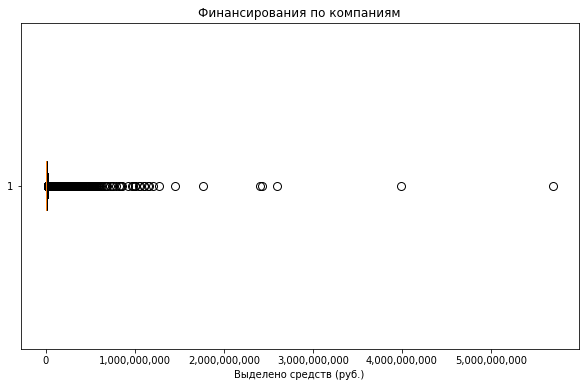

In [38]:
grouped = only_finance.groupby('name', as_index=False)['funding_total'].sum()

stats = grouped['funding_total'].describe()
pd.options.display.float_format = '{:,.0f}'.format
print(stats)

filtered_zero = grouped[grouped['funding_total'] > 0]

plt.figure(figsize=(10, 6))
box = plt.boxplot(filtered_zero['funding_total'], vert=False, patch_artist=True, 
                  boxprops=dict(facecolor="#073a5c"), 
                  flierprops=dict(marker='o', color='#84b6d9', markersize=8)) 
plt.xlabel("Выделено средств (руб.)")
plt.title("Финансирования по компаниям")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()

По боксплоту видно, что очень много значений, больших, чем третий квартиль. С ними не получится построить красивую гистограмму, поэтому используем логарифмическую шкалу, вместо обычной.

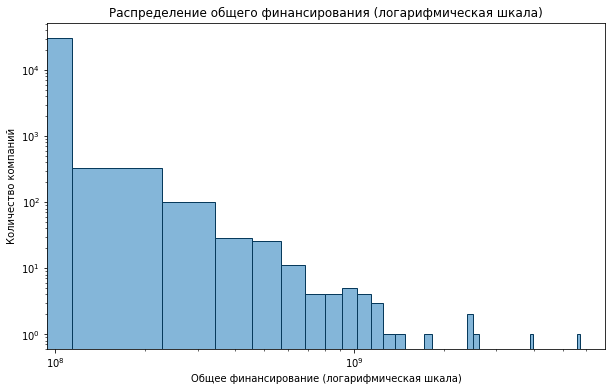

In [39]:
plt.figure(figsize=(10, 6))
plt.hist(grouped['funding_total'], bins=50, color='#84b6d9', edgecolor='#073a5c', log=True)
plt.xscale('log') 
plt.xlabel('Общее финансирование (логарифмическая шкала)')
plt.ylabel('Количество компаний')
plt.title('Распределение общего финансирования (логарифмическая шкала)')
plt.show()

По результатам анализа, можно говорить о наличии выбросов (выбросов в наборе данных, физически они, скорее всего, доольно осмысленны- большим компаниям требуются бОльшие вложения). При средних вложениях в 10 млн, медиана проходит на 600 тыс. А разница между 75% значений и максимальным значением в 5,5 млрд, и на боксплоте видно, что две компании сильно выбиваются по сумме вложений- они и подпортили медианное значение.


### 3.3. Куплены забесплатно?


In [40]:
car.fillna({'company_id': 0}, inplace=True)
aquis.fillna({'acquired_company_id': 0}, inplace=True)

car['company_id'] = car['company_id'].astype(int)
aquis['acquired_company_id'] = aquis['acquired_company_id'].astype(int)

acquired = pd.merge(car, aquis, left_on='company_id', right_on='acquired_company_id', how='outer')


In [41]:
for_free = acquired[(acquired['status'] == 'acquired') & (acquired['funding_total'] > 0) & ((acquired['price_amount'] == 0) |(acquired['price_amount'] == 1))]
for_free[['name', 'funding_total', 'price_amount']]

,name,funding_total,price_amount
30,Jumptap,"121,500,000",0
31,Jumptap,"121,500,000",0
32,Jumptap,"121,500,000",0
33,Jumptap,"121,500,000",0
34,Jumptap,"121,500,000",0
...,...,...,...
52319,UBmatrix,"5,172,350",0
52320,UBmatrix,"5,172,350",0
52322,wunderloop,"10,000,000",0
52341,Zimbra,"14,500,000",0


In [42]:
q1 = np.percentile(for_free['funding_total'], 25)
q2 = np.percentile(for_free['funding_total'], 50)
q3 = np.percentile(for_free['funding_total'], 75)
iqr = q3 - q1

lower = q2 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f"Первый квартиль: {q1:,.0f}")
print(f"Медиана: {q2:,.0f}")
print(f"Третий квартиль: {q3:,.0f}")
print(f"Интерквартильный размах: {iqr:,.0f}")
print(f"Нижняя граница выбросов: {lower:,.0f}")
print(f"Верхняя граница выбросов: {upper:,.0f}")

Первый квартиль: 3,000,000
Медиана: 10,000,000
Третий квартиль: 25,089,300
Интерквартильный размах: 22,089,300
Нижняя граница выбросов: -23,133,950
Верхняя граница выбросов: 58,223,250


Нижняя граница выбросов получилась отрицательной из-за большого интерквартильного размаха. Попробуем посмотреть, а есть ли вообще в наборе выбросы снизу:

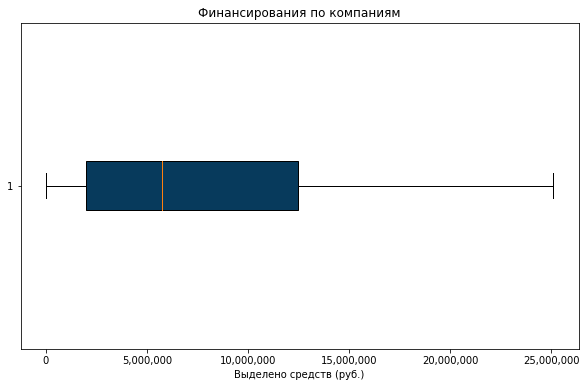

In [43]:
filtered = for_free[for_free["funding_total"] <= q3]

plt.figure(figsize=(10, 6))
box = plt.boxplot(filtered['funding_total'], vert=False, patch_artist=True, 
                  boxprops=dict(facecolor="#073a5c"), 
                  flierprops=dict(marker='o', color='#84b6d9', markersize=8)) 
plt.xlabel("Выделено средств (руб.)")
plt.title("Финансирования по компаниям")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()

Все значения лежат в пределах 1,5 интерквартильного размаха, значит можно говорить только о выбросах сверху. 

In [44]:
percentile = np.mean(for_free['funding_total'] <= upper) * 100
print(f"Верхняя граница выбросов соответсвует {percentile:.0f} процентилю")

Верхняя граница выбросов соответсвует 93 процентилю


Можно судить о нормальном распределении значений.

Интересно, в какие компании вложили много денег, но в итоге выкупили за бесценок:

In [45]:
expensive = for_free[for_free["funding_total"] > q3]
expensive[['name', 'category_code', 'funding_total', 'price_amount']]

,name,category_code,funding_total,price_amount
30,Jumptap,mobile,"121,500,000",0
31,Jumptap,mobile,"121,500,000",0
32,Jumptap,mobile,"121,500,000",0
33,Jumptap,mobile,"121,500,000",0
34,Jumptap,mobile,"121,500,000",0
...,...,...,...,...
52072,iSkoot,mobile,"32,200,000",0
52073,iSkoot,mobile,"32,200,000",0
52074,iSkoot,mobile,"32,200,000",0
52135,CyOptics,semiconductor,"77,000,000",0


In [46]:
value_counts = expensive['category_code'].value_counts()
print(value_counts)

software            117
mobile               93
biotech              73
web                  68
enterprise           61
cleantech            45
games_video          41
semiconductor        38
advertising          36
network_hosting      35
hardware             21
ecommerce            21
search               14
analytics            11
security             10
health               10
messaging             9
medical               9
social                6
other                 6
public_relations      6
finance               4
music                 4
transportation        4
fashion               4
travel                3
news                  2
consulting            1
Name: category_code, dtype: int64


Чаще всего по такой схеме покупали компании, занимающиеся разработкой ПО, мобильными телефонами и биотехнологические компании. 

In [47]:
cnt = for_free[for_free["funding_total"] < 0].count()
print(cnt)

company_id              0
name                    0
category_code           0
status                  0
founded_at              0
closed_at               0
domain                  0
network_username        0
country_code            0
investment_rounds       0
funding_rounds          0
funding_total           0
milestones              0
funding_round_id        0
funded_at               0
funding_round_type      0
raised_amount           0
pre_money_valuation     0
participants            0
is_first_round          0
is_last_round           0
id                      0
acquiring_company_id    0
acquired_company_id     0
term_code               0
price_amount            0
acquired_at             0
dtype: int64



### 3.4. Цены стартапов по категориям


Категории стартапов с типично высокими ценами покупки стартапов и значительным разбросом цен могут быть привлекательными для крупных инвесторов, которые готовы к высоким рискам ради потенциально больших доходов. Среди категорий стартапов выделите категории стартапов, характеризующиеся:
типично высокими ценами;
и наибольшим разбросом цен за стартап.
Объясните, почему решили составить топ именно из такого числа категорий и почему рассчитывали именно так.

Отберем компании, для которых цена покупки превышала цены 75% компаний. 

In [48]:
no_zero = aquis[aquis['price_amount'] > 0]
print(f"Всего компаний: {aquis.shape[0]}")
print(f"Компаний с ненулевой стоимостью: {no_zero.shape[0]}")

Всего компаний: 9407
Компаний с ненулевой стоимостью: 2476


In [49]:
no_zero.head(5)

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


In [50]:
df_company.head(5)

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,funding_total,milestones,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,...,"39,750,000",5,888,2005,series-a,"5,250,000",0,2,0,1
15,1001,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0,...,"5,000,000",3,"1,644",2008,series-a,"5,000,000",0,3,1,1
20,10014,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0,...,0,4,"6,682",2008,angel,0,0,1,1,1
21,10015,Fitbit,health,operating,2007-10-01,NaT,fitbit.com,fitbit,USA,0,...,"68,069,200",0,"3,619",2008,series-a,"2,000,000",0,2,0,1
26,100155,MTPV,cleantech,operating,2003-01-01,NaT,mtpv.com,NaN,USA,0,...,"10,125,300",1,"25,184",2011,series-b,"6,500,000",0,3,0,0


Для определения категорий присоединим таблицу с данными о компаниях к таблице с информацией о покупках:

In [51]:
df_company['company_id'].isna().sum()

1

In [52]:
df_company['company_id'] = df_company['company_id'].fillna(0).astype(int)

In [53]:
buy = pd.merge(no_zero, df_company, left_on='acquired_company_id', right_on='company_id', how='left')
buy.head(5)

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at,company_id,name,category_code,status,...,funding_total,milestones,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1,11,10,NaN,20000000,2007-05-30,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
1,7,59,72,cash,60000000,2007-07-01,72,GrandCentral,mobile,acquired,...,"4,000,000",4,52,2006,series-a,"4,000,000",0,1,1,1
2,8,24,132,cash,280000000,2007-05-01,132,Last.fm,music,acquired,...,"5,000,000",5,114,2006,series-a,"5,000,000",0,1,1,1
3,9,59,155,cash,100000000,2007-06-01,155,FeedBurner,web,acquired,...,"8,000,000",4,130,2004,series-a,"1,000,000",0,0,0,1
4,10,212,215,cash,25000000,2007-07-01,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN


Получился датасет с данными о компаниях, которые купили. Теперь попробуем выделить типичные цены по категориям и найти компании, которые выпали из общего тренда:

In [54]:
med = buy.groupby('category_code')['price_amount'].median().reset_index()
med

,category_code,price_amount
0,advertising,70000000
1,analytics,200000000
2,automotive,43000000
3,biotech,250000000
4,cleantech,158000000
5,consulting,122500000
6,ecommerce,200000000
7,education,10000000
8,enterprise,125000000
9,fashion,270000000


In [55]:
med = buy.groupby('category_code')['price_amount'].median().reset_index()
med = med.rename(columns={'price_amount': 'category_median'})

df_median = buy.merge(med, on='category_code', how='left')

above_median = df_median[df_median['price_amount'] > df_median['category_median']]
above_median

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at,company_id,name,category_code,status,...,milestones,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round,category_median
2,8,24,132,cash,280000000,2007-05-01,132,Last.fm,music,acquired,...,5,114,2006,series-a,"5,000,000",0,1,1,1,"4,860,000"
3,9,59,155,cash,100000000,2007-06-01,155,FeedBurner,web,acquired,...,4,130,2004,series-a,"1,000,000",0,0,0,1,"50,000,000"
6,15,20,333,stock,1500000000,2002-07-08,333,PayPal,finance,acquired,...,5,284,2001,series-c+,"90,000,000",0,5,1,0,"141,500,000"
10,19,355,354,cash,300000000,2005-04-01,354,Snapfish,network_hosting,acquired,...,4,299,1999,series-a,"7,500,000",0,1,0,1,"99,500,000"
27,50,25,655,cash,102000000,2006-04-01,655,Xfire,games_video,acquired,...,4,"25,802",2011,venture,"4,000,000",0,2,0,1,"65,000,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2406,10315,1654,5032,NaN,345000000,2013-07-18,"5,032",PrimeSense,hardware,acquired,...,2,"2,185",2008,series-b,"20,400,000",0,3,0,0,"100,000,000"
2413,10333,74770,173430,NaN,200000000,2013-11-19,"173,430",Tier 3,enterprise,acquired,...,1,"21,860",2011,series-a,"8,500,000",0,2,0,1,"125,000,000"
2436,10423,424,5700,cash,370000000,2013-12-02,"5,700",Prolexic Technologies,enterprise,acquired,...,2,"22,141",2011,venture,"13,900,000",0,1,0,1,"125,000,000"
2450,10454,39669,141501,NaN,464000000,2013-12-04,"141,501",Rempex Pharmaceuticals,biotech,acquired,...,1,"26,467",2011,series-b,"67,500,000",0,5,1,1,"250,000,000"


In [56]:
print(f"Компаний с высокими ценами {above_median.shape[0]} штук")

Компаний с высокими ценами 357 штук


In [57]:
above_median['category_code'].value_counts()

software            61
biotech             46
web                 42
mobile              34
enterprise          24
games_video         20
advertising         20
semiconductor       15
network_hosting     15
public_relations    12
hardware            11
security             9
cleantech            8
ecommerce            7
other                5
search               5
finance              3
news                 3
messaging            2
social               2
consulting           2
medical              2
photo_video          2
health               2
manufacturing        1
analytics            1
music                1
travel               1
real_estate          1
Name: category_code, dtype: int64

В итоге получилось, что 350 компаний продались по ценам выше среднего. Из них больше всего компаний, занимающихся разработкой ПО, биотехнологиями, сайтами и мобильными приложениями.

Найдем медану разброса и выберем компании со значениями разброса больше медианных:

In [58]:
agg = buy.groupby('category_code')['price_amount'].agg(['min', 'max', 'count']).reset_index()
agg = agg[agg['count'] > 1]
agg['price_spread'] = agg['max'] - agg['min']

median_spread = agg.groupby('category_code')['price_spread'].median().reset_index()
median_spread = median_spread.rename(columns={'price_spread': 'median_price_spread'})
median_spread

,category_code,median_price_spread
0,advertising,1798600000
1,analytics,183000000
2,biotech,2299891000
3,cleantech,929550000
4,consulting,256000000
5,ecommerce,538500000
6,enterprise,1594880000
7,finance,1498800000
8,games_video,1649730000
9,hardware,1172500000


In [59]:
agg = agg.merge(median_spread, on='category_code', how='left')
high_spread_companies = agg[agg['price_spread'] > agg['median_price_spread']]

# 4. Берём только те строки из исходного df, которые соответствуют этим компаниям
result = buy.merge(
    high_spread_companies['category_code'],
    on='category_code',
    how='inner'
)
result

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at,company_id,name,category_code,status,...,funding_total,milestones,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round



### 3.5. Сколько раундов продержится стартап перед покупкой

- Необходимо проанализировать столбец `funding_rounds`. Исследуйте значения столбца. Заказчика интересует типичное значение количества раундов для каждого возможного статуса стартапа.
- Постройте график, который отображает, сколько в среднем раундов финансирования проходило для стартапов из каждой группы. Сделайте выводы.

In [60]:
were_rounds = car[car['funding_rounds'] > 0]

In [61]:
median_rounds = were_rounds.groupby('status')['funding_rounds'].median().reset_index()
median_rounds

,status,funding_rounds
0,acquired,2
1,closed,1
2,ipo,4
3,operating,2


Чаще всего купленые компании не финансировали вовсе, закрытые пытались спасти один раз, а компании, выдвинутые на IPO, финансировали по два раза. 

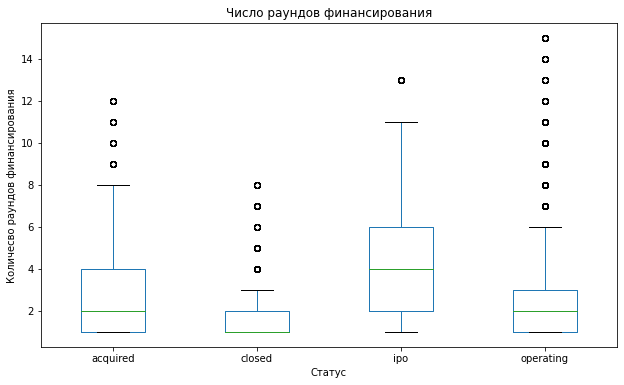

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))
box = were_rounds.boxplot(column='funding_rounds', by='status', ax=ax, grid=False)

plt.xlabel("Статус")
plt.ylabel("Количесво раундов финансирования")
plt.title("Число раундов финансирования")
plt.suptitle("")

plt.show()

При покупке, компании чаще всего проходили 2 раунда финансирования, при довольная большая часть компаний прошли по больше 2-х раундов финансирования. Закрытые компании в 75% случаев приходили 1-2 раунда финансирования, больше итераций было у единиц. Вышедшие на IPO компании финансировали куда чаще- половину не менее четырех раз, а еще четверть- до шести раз. Так же такие компании имеют наибольший размах значений. 


## Шаг 4. Итоговый вывод и рекомендации

После предобработки данных было выяснено, что не для всех сотрудников есть данные об образовании, причем для компаний средних размеров этот показатель наилучший. 

Так же оказалось, что один из датасетов был собран из двух других, поэтому не обо всех компаниях имелась информация о финансировании. 

Изучила типичный размер финансирования. Несколько компаний получили аномально большие средства (вероятно, из-за того, что сами компании довольно крупные), но в среднем компании получали до миллиона рублей. 

Некоторые компании купили за 0 или 1 доллар, при этом до покупки известно, что в них поступали инвестиции. Такие компании в среднем получали 10 млн рублей, но в значениях имелись значительные выбросы- биотехнологические компании и компании, занимающиеся разработкой ПО получали большие инвестиции, но в итоге были проданы за бесценок.

Так же для инвесторов, готовых на большие риски, отобрали 1500 компаний, которые купили за очень высокие цены или перепродали с большой разницей от прошлой цены покупки.

Изучили, как распределялось число раундов финансирования при разных исходах. При покупке, компании чаще всего вовсе не финансировали (лишь несколько компаний прошли 1-2 раунда финансирования). Закрытые компании в 75% случаев пытались спасти 1-2 раза, редко больше. Вышедшие на IPO компании финансировали куда чаще- половину не менее двух раз, а еще четверть- до пяти раз. Так же такие компании имеют наибольший размах значений. 

Если планируется покупка компаний из данных, то в первую очередь стоит присмотреться к сотрудникам и собрать данные об их образовании, которых критически не хватает. 
Заказчик может рассмотреть 31 тысячу компаний, которые получали финансирование, но лучшими мы будем считать те, в которые вкладывали больше денег. К компаниями с наибольшими вложениями, в основном относятся компании, занимающиеся разработкой ПО, веб-сайтами и мобильными приложениями, а так же биотехнологические компании. При выборе компаний для инвестирования стоит обратить внимания на них. Лично мой совет- выбирайте биотехнологические компании. Им нужно много инвестиций, но как только они выпускают продукт, все вложения окупаются с лихвой. 